# Data Ingestion 
This notebook details the initial development of the data ingestion scripts

## to do 
- resolve nans being set to 1970
- resolve 24 hour issue 
- create scripts for creating table and storing values 

old 
Notes
------
- The vehicle id and timestamp can be used together as the unique id
- Before loading feed entity it should be check that the most recent timestamp for vehicle should not be repeated. 




## Packages

In [1]:
import os 
from google.transit import gtfs_realtime_pb2
import requests
from time import sleep
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from typing import Optional, List
import sys 

# Add parent directory to sys.path for module imports
sys.path.append(os.path.dirname(os.getcwd()))
from data_ingestion.utils import (
    fetch_gtfs_data, parse_gtfs_data, get_field
)

## Functions

In [2]:

def get_dicts_from_feed(header, entity) -> dict:
    """
    Convert a FeedEntity to a dictionary, handling missing fields gracefully.

    Parameters:
    -----------
    header: gtfs_realtime_pb2.FeedHeader
        The FeedHeader containing metadata about the feed.
        
    entity: gtfs_realtime_pb2.FeedEntity
        The FeedEntity to convert.

    Returns
    -------
    dict
        A dictionary representation of the FeedEntity.
    """

    trip_update = get_field(entity, "trip_update")
    trip = get_field(trip_update, "trip") 
    stop_time_update = get_field(trip_update, "stop_time_update")
    base_dict = {
        "feed_timestamp": get_field(header, "timestamp"),
        "trip_id": get_field(trip, "trip_id"),
        "trip_start_time": get_field(trip, "start_time"),
        "trip_start_date": get_field(trip, "start_date"),
        "trip_schedule_relationship": get_field(trip, "schedule_relationship"),
        "trip_route_id": get_field(trip, "route_id"),
        "trip_direction_id": get_field(trip, "direction_id"),
    }
    list_dicts = []
    for stu in stop_time_update:
        dict_str = base_dict.copy()
        arrival = get_field(stu, "arrival")
        departure = get_field(stu, "departure")
        dict_str.update({
            "stop_sequence": get_field(stu, "stop_sequence"),
            "stop_id": get_field(stu, "stop_id"),
            "schedule_relationship": get_field(stu, "schedule_relationship"),
            "arrival_delay": get_field(arrival, "delay"),
            "arrival_time": get_field(arrival, "time"),
            "arrival_uncertainty": get_field(arrival, "uncertainty"),
            "departure_delay": get_field(departure, "delay"),
            "departure_time": get_field(departure, "time"),
            "departure_uncertainty": get_field(departure, "uncertainty"),
        })
        list_dicts.append(dict_str)

    return list_dicts


def extract_feed_info(feed: gtfs_realtime_pb2.FeedEntity) -> List[dict]:
    """
    Convert a FeedEntity to a dictionary, handling missing fields gracefully.

    Parameters:
    -----------
    feed: gtfs_realtime_pb2.Feed
        The Feed to convert.

    Returns
    -------
    List[dict]
        A list of dictionary representations of the FeedEntities.
    """
    header = get_field(feed, "header")
    list_entity = get_field(feed, "entity")
    list_dict_entities = []
    for entity in list_entity:
        list_dict_entities.extend(get_dicts_from_feed(header, entity))

    return list_dict_entities

def get_df_feed(list_dict_entities: List[dict], trip_estimates: dict) -> pd.DataFrame:
    """
    Convert a list of dictionary representations of FeedEntities to a DataFrame.

    Parameters:
    -----------
    list_dict_entities: List[dict]
        A list of dictionary representations of the FeedEntities.

    trip_estimates: dict
        A dictionary mapping trip IDs and stop IDs to their current arrival and departure estimates.
        Formatted as follows:
        {
            trip_id: {
                stop_id: {
                    'arrival_delay': ...,
                    'arrival_time': ...,
                    'arrival_uncertainty': ...,
                    'departure_delay': ...,
                    'departure_time': ...,
                    'departure_uncertainty': ...
                },
                ...
            },
            ...
        }   

    Returns
    -------
    df_feed: pd.DataFrame
        A DataFrame representation of the FeedEntities.

    trip_estimates: dict
        A dictionary mapping trip IDs and stop IDs to their latest arrival and departure estimates.

        Formatted as follows:
        {
            trip_id: {
                stop_id: {
                    'arrival_delay': ...,
                    'arrival_time': ...,
                    'arrival_uncertainty': ...,
                    'departure_delay': ...,
                    'departure_time': ...,
                    'departure_uncertainty': ...
                },
                ...
            },
            ...
        }

    """
    #TODO: Remove duplicate logic for now, just keep all entries
    check_cols = ['arrival_delay', 'arrival_time', 'arrival_uncertainty', 'departure_delay', 'departure_time', 'departure_uncertainty']
    list_non_duplicates = []
    for dict_entity in list_dict_entities:
        trip_id = dict_entity['trip_id']
        stop_id = dict_entity['stop_id']

        insert_record = False 
        if trip_id not in trip_estimates:
            insert_record = True
            trip_estimates[trip_id] = {}
        elif stop_id not in trip_estimates[trip_id]:
            insert_record = True
        else:
            for col in check_cols:
                if dict_entity[col] != trip_estimates[trip_id][stop_id][col]:
                    insert_record = True
                    break
            
        if insert_record:
            list_non_duplicates.append(dict_entity)
            trip_estimates[trip_id][stop_id] = {col: dict_entity[col] for col in check_cols}

    df_feed = pd.DataFrame(list_non_duplicates)
    return df_feed, trip_estimates

def format_data(df_feed: pd.DataFrame) -> pd.DataFrame:
    """
    Format the DataFrame by converting timestamp columns to datetime.

    Parameters
    ----------
    df_feed: pd.DataFrame
        The DataFrame to format.

    Returns
    -------
    pd.DataFrame
        The formatted DataFrame.
    """
    df_feed['trip_start_timestamp'] = pd.to_datetime(
        df_feed['trip_start_date'] + ' ' + df_feed['trip_start_time'], 
        format='%Y%m%d %H:%M:%S', errors='coerce'
    )
    time_columns = ["feed_timestamp", "arrival_time", "departure_time"]
    for col in time_columns:
        df_feed[col] = pd.to_datetime(df_feed[col], unit='s')

    return df_feed

def format_data_for_db(df_feed: pd.DataFrame) -> pd.DataFrame:
    """
    Format the DataFrame for database insertion by replacing NaN with None.

    Parameters
    ----------
    df_feed: pd.DataFrame
        The DataFrame to format.

    Returns
    -------
    pd.DataFrame
        The formatted DataFrame.
    """

    process_cols = df_feed.dtypes[df_feed.dtypes==object]
    for col in process_cols.index:
        df_feed[col] = df_feed[col].apply(lambda x: x if x != '' else None)
    if 'trip_start_time' in df_feed.columns:
        del df_feed['trip_start_time']
    if 'trip_start_date' in df_feed.columns:
        del df_feed['trip_start_date']
    #col_types = {
    #    'entity_id': int,
    #    'trip_id': str,
    #    'trip_schedule_relationship': int,
    #    'trip_route_id': str,
    #    'trip_direction_id': int,
    #    'position_latitude': float,
    #    'position_longitude': float,
    #    'position_bearing': float,
    #    'position_odometer': float,
    #    'position_speed': float,
    #    'current_stop_sequence': int,
    #    'current_status': int,
    #    'congestion_level': int,
    #    'stop_id': str,
    #    'vehicle_id': int,
    #    'vehicle_label': int
    #}
    #for col, col_type in col_types.items():
    #    if col in df_feed.columns:
    #        df_feed[col] = df_feed[col].astype(col_type)

    #drop cols with No trip start timestamp
    #df_feed = df_feed[~df_feed['trip_start_timestamp'].isna()].reset_index(drop=True)
    return df_feed

In [3]:
CREATE_TABLE_QUERY = """
CREATE TABLE IF NOT EXISTS TRANSIT_TRIP_DATA (
    id INT AUTO_INCREMENT PRIMARY KEY,
    feed_timestamp TIMESTAMP,
    trip_id VARCHAR(50),
    trip_schedule_relationship INT,
    trip_route_id VARCHAR(20),
    trip_direction_id INT,
    stop_sequence INT,
    stop_id VARCHAR(50),
    schedule_relationship INT,
    arrival_delay INT,
    arrival_time TIMESTAMP,
    arrival_uncertainty INT,
    departure_delay INT,
    departure_time TIMESTAMP,
    departure_uncertainty INT,
);
"""
INSERT_DATA_QUERY = """
INSERT INTO TRANSIT_TRIP_DATA (
    feed_timestamp,
    trip_id,
    trip_schedule_relationship,
    trip_route_id,
    trip_direction_id,
    stop_sequence,
    stop_id,
    schedule_relationship,
    arrival_delay,
    arrival_time,
    arrival_uncertainty,
    departure_delay,
    departure_time,
    departure_uncertainty
) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s);
"""

## Constants

In [4]:
realtime_trip_updates_url = "https://bct.tmix.se/gtfs-realtime/tripupdates.pb?operatorIds=47"
realtime_vehicle_updates_url = "https://bct.tmix.se/gtfs-realtime/vehicleupdates.pb?operatorIds=47"

root_dir = os.path.dirname(os.path.abspath("."))  # Fixed typo from dirname to dir
data_dir = os.path.join(root_dir, "data")
src_dir = os.path.join(root_dir, "notebooks")
os.makedirs(data_dir, exist_ok=True)

df_path = os.path.join(data_dir, "trip_updates.csv")


# script parameter 
download = True

## Get Feed

In [5]:
if download:
    df = pd.DataFrame()
    trip_current_estimates = {}
    for i in range(200):
        data = fetch_gtfs_data(realtime_trip_updates_url)
        if data:
            feed = parse_gtfs_data(data)
            list_dict_entities = extract_feed_info(feed)
            print(f"Feed has {len(feed.entity)} entities.")
            df_feed, trip_current_estimates = get_df_feed(
                list_dict_entities, trip_current_estimates)
            if not df_feed.empty:
                df_feed = format_data(df_feed)
                df = pd.concat([df, df_feed], ignore_index=True)
        sleep(1)
    df.to_csv(df_path, index=False)
else:
    df = pd.read_csv(df_path)

Feed has 95 entities.
Feed has 95 entities.
Feed has 95 entities.
Feed has 95 entities.
Feed has 95 entities.
Feed has 95 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 94 entities.
Feed has 9

In [6]:
df

,feed_timestamp,trip_id,trip_start_time,trip_start_date,trip_schedule_relationship,trip_route_id,trip_direction_id,stop_sequence,stop_id,schedule_relationship,arrival_delay,arrival_time,arrival_uncertainty,departure_delay,departure_time,departure_uncertainty,trip_start_timestamp
0,2026-01-11 03:07:26,2847591:11783563:11791749,20:14:00,20260110,0,97-KEL,0,1,140004,0,0,1970-01-01 00:00:00,0,0,2026-01-11 04:14:00,0,2026-01-10 20:14:00
1,2026-01-11 03:07:26,2847591:11783563:11791749,20:14:00,20260110,0,97-KEL,0,2,140071,0,0,2026-01-11 04:16:00,0,0,2026-01-11 04:16:00,0,2026-01-10 20:14:00
2,2026-01-11 03:07:26,2847591:11783563:11791749,20:14:00,20260110,0,97-KEL,0,3,140007,0,0,2026-01-11 04:21:00,0,0,2026-01-11 04:21:00,0,2026-01-10 20:14:00
3,2026-01-11 03:07:26,2847591:11783563:11791749,20:14:00,20260110,0,97-KEL,0,4,140073,0,0,2026-01-11 04:23:00,0,0,2026-01-11 04:23:00,0,2026-01-10 20:14:00
4,2026-01-11 03:07:26,2847591:11783563:11791749,20:14:00,20260110,0,97-KEL,0,5,103745,0,0,2026-01-11 04:27:00,0,0,2026-01-11 04:27:00,0,2026-01-10 20:14:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7599,2026-01-11 03:12:33,2847910:11785225:11790891,20:07:00,20260110,0,21-KEL,1,37,140006,0,0,2026-01-11 04:31:00,0,0,1970-01-01 00:00:00,0,2026-01-10 20:07:00
7600,2026-01-11 03:12:33,2847926:11784733:11791734,21:11:00,20260110,0,21-KEL,1,1,140006,0,0,1970-01-01 00:00:00,0,0,2026-01-11 05:11:00,0,2026-01-10 21:11:00
7601,2026-01-11 03:12:33,2847926:11784733:11791734,21:11:00,20260110,0,21-KEL,1,37,140006,0,0,2026-01-11 05:35:00,0,0,1970-01-01 00:00:00,0,2026-01-10 21:11:00
7602,2026-01-11 03:12:33,2848111:11783686:11790774,21:00:00,20260110,0,2-KEL,0,1,102859,0,0,1970-01-01 00:00:00,0,0,2026-01-11 05:00:00,0,2026-01-10 21:00:00


In [41]:
dict1 = {}

In [42]:
dict1['2847591:11783563:11791749'][67]

KeyError: '2847591:11783563:11791749'

In [9]:
df.columns

Index(['feed_timestamp', 'trip_id', 'trip_start_time', 'trip_start_date',
       'trip_schedule_relationship', 'trip_route_id', 'trip_direction_id',
       'stop_sequence', 'stop_id', 'schedule_relationship', 'arrival_delay',
       'arrival_time', 'arrival_uncertainty', 'departure_delay',
       'departure_time', 'departure_uncertainty', 'trip_start_timestamp'],
      dtype='object')

In [10]:
df[['feed_timestamp', 'trip_start_time', 'trip_start_date', 'arrival_time', 'departure_time', 'trip_start_timestamp']].head()

,feed_timestamp,trip_start_time,trip_start_date,arrival_time,departure_time,trip_start_timestamp
0,2026-01-11 02:13:30,18:21:00,20260110,1970-01-01 00:00:00,2026-01-11 02:24:04,2026-01-10 18:21:00
1,2026-01-11 02:13:30,18:21:00,20260110,2026-01-11 02:24:04,2026-01-11 02:24:04,2026-01-10 18:21:00
2,2026-01-11 02:13:30,18:21:00,20260110,2026-01-11 02:25:04,2026-01-11 02:25:04,2026-01-10 18:21:00
3,2026-01-11 02:13:30,18:21:00,20260110,2026-01-11 02:27:04,2026-01-11 02:27:04,2026-01-10 18:21:00
4,2026-01-11 02:13:30,18:21:00,20260110,2026-01-11 02:32:04,2026-01-11 02:32:04,2026-01-10 18:21:00


In [13]:
df['trip_id'].value_counts()

trip_id
2848062:11774058:11790900    10600
2848055:11778686:11791353    10600
2848057:11775273:11791126    10600
2848050:11788596:11791280     9800
2847949:11779967:11791401     9200
                             ...  
2847606:11779071:11791744      495
2847526:11788443:11791883      408
2847528:11786566:11791739       33
2847710:11787749:11792161       33
2847503:11788257:11791353       16
Name: count, Length: 111, dtype: int64

In [23]:
mask = df['trip_id'] == "2848062:11774058:11790900"
df_trip = df[mask]
df_stop_1 = df_trip[df_trip['stop_sequence'] == 2]

In [32]:
df_trip

,feed_timestamp,trip_id,trip_start_time,trip_start_date,trip_schedule_relationship,trip_route_id,trip_direction_id,stop_sequence,stop_id,schedule_relationship,arrival_delay,arrival_time,arrival_uncertainty,departure_delay,departure_time,departure_uncertainty,trip_start_timestamp
291,2026-01-11 02:13:30,2848062:11774058:11790900,20:00:00,20260110,0,11-KEL,1,1,140316,0,0,1970-01-01 00:00:00,0,0,2026-01-11 04:00:00,0,2026-01-10 20:00:00
292,2026-01-11 02:13:30,2848062:11774058:11790900,20:00:00,20260110,0,11-KEL,1,2,103378,0,0,2026-01-11 04:01:00,0,0,2026-01-11 04:01:00,0,2026-01-10 20:00:00
293,2026-01-11 02:13:30,2848062:11774058:11790900,20:00:00,20260110,0,11-KEL,1,3,140304,0,0,2026-01-11 04:02:00,0,0,2026-01-11 04:02:00,0,2026-01-10 20:00:00
294,2026-01-11 02:13:30,2848062:11774058:11790900,20:00:00,20260110,0,11-KEL,1,4,103421,0,0,2026-01-11 04:03:00,0,0,2026-01-11 04:03:00,0,2026-01-10 20:00:00
295,2026-01-11 02:13:30,2848062:11774058:11790900,20:00:00,20260110,0,11-KEL,1,5,103428,0,0,2026-01-11 04:04:00,0,0,2026-01-11 04:04:00,0,2026-01-10 20:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510105,2026-01-11 02:18:55,2848062:11774058:11790900,20:00:00,20260110,0,11-KEL,1,49,102906,0,0,2026-01-11 04:41:00,0,0,2026-01-11 04:41:00,0,2026-01-10 20:00:00
510106,2026-01-11 02:18:55,2848062:11774058:11790900,20:00:00,20260110,0,11-KEL,1,50,102897,0,0,2026-01-11 04:42:00,0,0,2026-01-11 04:42:00,0,2026-01-10 20:00:00
510107,2026-01-11 02:18:55,2848062:11774058:11790900,20:00:00,20260110,0,11-KEL,1,51,102887,0,0,2026-01-11 04:43:00,0,0,2026-01-11 04:43:00,0,2026-01-10 20:00:00
510108,2026-01-11 02:18:55,2848062:11774058:11790900,20:00:00,20260110,0,11-KEL,1,52,102874,0,0,2026-01-11 04:45:00,0,0,2026-01-11 04:45:00,0,2026-01-10 20:00:00


In [29]:
df['trip_id'].nunique()

111

In [28]:
df.groupby('trip_id')['trip_route_id'].value_counts().reset_index()

,trip_id,trip_route_id,count
0,2847475:11779435:11791719,1-KEL,1765
1,2847477:11775983:11791719,1-KEL,4800
2,2847478:11781365:11791719,1-KEL,4800
3,2847503:11788257:11791353,11-KEL,16
4,2847522:11778415:11790900,11-KEL,6872
...,...,...,...
106,2848234:11776795:11791762,10-KEL,3544
107,2848238:11773862:11791311,98-KEL,3200
108,2848239:11780369:11791311,98-KEL,3200
109,2848240:11777646:11791280,2-KEL,3800


In [31]:
df.groupby('trip_id')['trip_direction_id'].value_counts().reset_index()

,trip_id,trip_direction_id,count
0,2847475:11779435:11791719,0,1765
1,2847477:11775983:11791719,0,4800
2,2847478:11781365:11791719,0,4800
3,2847503:11788257:11791353,0,16
4,2847522:11778415:11790900,1,6872
...,...,...,...
106,2848234:11776795:11791762,0,3544
107,2848238:11773862:11791311,1,3200
108,2848239:11780369:11791311,0,3200
109,2848240:11777646:11791280,0,3800


In [25]:
df_stop_1.head()

,feed_timestamp,trip_id,trip_start_time,trip_start_date,trip_schedule_relationship,trip_route_id,trip_direction_id,stop_sequence,stop_id,schedule_relationship,arrival_delay,arrival_time,arrival_uncertainty,departure_delay,departure_time,departure_uncertainty,trip_start_timestamp
292,2026-01-11 02:13:30,2848062:11774058:11790900,20:00:00,20260110,0,11-KEL,1,2,103378,0,0,2026-01-11 04:01:00,0,0,2026-01-11 04:01:00,0,2026-01-10 20:00:00
2767,2026-01-11 02:13:30,2848062:11774058:11790900,20:00:00,20260110,0,11-KEL,1,2,103378,0,0,2026-01-11 04:01:00,0,0,2026-01-11 04:01:00,0,2026-01-10 20:00:00
5242,2026-01-11 02:13:30,2848062:11774058:11790900,20:00:00,20260110,0,11-KEL,1,2,103378,0,0,2026-01-11 04:01:00,0,0,2026-01-11 04:01:00,0,2026-01-10 20:00:00
7717,2026-01-11 02:13:30,2848062:11774058:11790900,20:00:00,20260110,0,11-KEL,1,2,103378,0,0,2026-01-11 04:01:00,0,0,2026-01-11 04:01:00,0,2026-01-10 20:00:00
10192,2026-01-11 02:13:30,2848062:11774058:11790900,20:00:00,20260110,0,11-KEL,1,2,103378,0,0,2026-01-11 04:01:00,0,0,2026-01-11 04:01:00,0,2026-01-10 20:00:00


In [8]:
df

,feed_timestamp,trip_id,trip_start_time,trip_start_date,trip_schedule_relationship,trip_route_id,trip_direction_id,stop_sequence,stop_id,schedule_relationship,arrival_delay,arrival_time,arrival_uncertainty,departure_delay,departure_time,departure_uncertainty,trip_start_timestamp
0,2026-01-11 02:13:30,2847821:11780494:11791339,18:21:00,20260110,0,23-KEL,1,1,103660,0,0,1970-01-01 00:00:00,0,184,2026-01-11 02:24:04,0,2026-01-10 18:21:00
1,2026-01-11 02:13:30,2847821:11780494:11791339,18:21:00,20260110,0,23-KEL,1,2,103657,0,184,2026-01-11 02:24:04,0,184,2026-01-11 02:24:04,0,2026-01-10 18:21:00
2,2026-01-11 02:13:30,2847821:11780494:11791339,18:21:00,20260110,0,23-KEL,1,3,103655,0,184,2026-01-11 02:25:04,0,184,2026-01-11 02:25:04,0,2026-01-10 18:21:00
3,2026-01-11 02:13:30,2847821:11780494:11791339,18:21:00,20260110,0,23-KEL,1,4,103652,0,184,2026-01-11 02:27:04,0,184,2026-01-11 02:27:04,0,2026-01-10 18:21:00
4,2026-01-11 02:13:30,2847821:11780494:11791339,18:21:00,20260110,0,23-KEL,1,5,103609,0,184,2026-01-11 02:32:04,0,184,2026-01-11 02:32:04,0,2026-01-10 18:21:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512311,2026-01-11 02:18:55,2847688:11788935:11791956,20:05:00,20260110,0,1-KEL,1,20,103152,0,0,2026-01-11 04:22:00,0,0,2026-01-11 04:22:00,0,2026-01-10 20:05:00
512312,2026-01-11 02:18:55,2847688:11788935:11791956,20:05:00,20260110,0,1-KEL,1,21,103185,0,0,2026-01-11 04:23:00,0,0,2026-01-11 04:23:00,0,2026-01-10 20:05:00
512313,2026-01-11 02:18:55,2847688:11788935:11791956,20:05:00,20260110,0,1-KEL,1,22,103342,0,0,2026-01-11 04:23:00,0,0,2026-01-11 04:23:00,0,2026-01-10 20:05:00
512314,2026-01-11 02:18:55,2847688:11788935:11791956,20:05:00,20260110,0,1-KEL,1,23,103801,0,0,2026-01-11 04:24:00,0,0,2026-01-11 04:24:00,0,2026-01-10 20:05:00


In [6]:
df.iloc[5767]

feed_timestamp                      2026-01-11 02:13:30
trip_id                       2848210:11779954:11791066
trip_start_time                                18:45:00
trip_start_date                                20260110
trip_schedule_relationship                            0
trip_route_id                                    10-KEL
trip_direction_id                                     0
stop_sequence                                        32
stop_id                                          140152
schedule_relationship                                 0
arrival_delay                                       -15
arrival_time                        2026-01-11 03:13:45
arrival_uncertainty                                   0
departure_delay                                     -15
departure_time                      2026-01-11 03:13:45
departure_uncertainty                                 0
trip_start_timestamp                2026-01-10 18:45:00
Name: 5767, dtype: object

In [7]:
df[df['trip_start_time']>'24:00:00']['trip_start_timestamp'].isna().sum()/len(df[df['trip_start_time']>'24:00:00'])

/tmp/ipykernel_5191/4049302262.py:1: RuntimeWarning: invalid value encountered in scalar divide
  df[df['trip_start_time']>'24:00:00']['trip_start_timestamp'].isna().sum()/len(df[df['trip_start_time']>'24:00:00'])


np.float64(nan)

In [86]:
df[df['trip_start_time']<'24:00:00']['trip_start_timestamp'].isna().sum()/len(df[df['trip_start_time']<'24:00:00'])

np.float64(0.0)

In [62]:
df_check

,feed_timestamp,trip_id,trip_start_time,trip_start_date,trip_schedule_relationship,trip_route_id,trip_direction_id,stop_sequence,stop_id,schedule_relationship,arrival_delay,arrival_time,arrival_uncertainty,departure_delay,departure_time,departure_uncertainty,trip_start_timestamp
0,2026-01-01 07:51:57,2781208:10200531:11791265,24:57:00,20251231,0,10-KEL,1,1,103327,0,0,1970-01-01 00:00:00,0,0,2026-01-01 08:57:00,0,NaT
1,2026-01-01 07:51:57,2781208:10200531:11791265,24:57:00,20251231,0,10-KEL,1,2,103343,0,0,2026-01-01 08:57:00,0,0,2026-01-01 08:57:00,0,NaT


In [101]:
df_trip = df[df['trip_id']=="2781626:10207723:10208700"]

In [104]:
df_trip

,feed_timestamp,trip_id,trip_start_time,trip_start_date,trip_schedule_relationship,trip_route_id,trip_direction_id,stop_sequence,stop_id,schedule_relationship,arrival_delay,arrival_time,arrival_uncertainty,departure_delay,departure_time,departure_uncertainty,trip_start_timestamp
572,2026-01-01 07:51:57,2781626:10207723:10208700,23:30:00,20251231,0,97-KEL,0,8,140003,0,92,2026-01-01 07:53:32,0,92,2026-01-01 07:53:32,0,2025-12-31 23:30:00
573,2026-01-01 07:51:57,2781626:10207723:10208700,23:30:00,20251231,0,97-KEL,0,9,102985,0,92,2026-01-01 07:55:32,0,92,2026-01-01 07:55:32,0,2025-12-31 23:30:00
574,2026-01-01 07:51:57,2781626:10207723:10208700,23:30:00,20251231,0,97-KEL,0,10,103067,0,92,2026-01-01 07:57:32,0,92,2026-01-01 07:57:32,0,2025-12-31 23:30:00
575,2026-01-01 07:51:57,2781626:10207723:10208700,23:30:00,20251231,0,97-KEL,0,11,103174,0,92,2026-01-01 07:59:32,0,92,2026-01-01 07:59:32,0,2025-12-31 23:30:00
576,2026-01-01 07:51:57,2781626:10207723:10208700,23:30:00,20251231,0,97-KEL,0,12,103263,0,92,2026-01-01 08:02:32,0,92,2026-01-01 08:02:32,0,2025-12-31 23:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112387,2026-01-01 07:56:46,2781626:10207723:10208700,23:30:00,20251231,0,97-KEL,0,14,140102,0,42,2026-01-01 08:08:42,0,0,1970-01-01 00:00:00,0,2025-12-31 23:30:00
112930,2026-01-01 07:56:46,2781626:10207723:10208700,23:30:00,20251231,0,97-KEL,0,11,103174,0,42,2026-01-01 07:58:42,0,42,2026-01-01 07:58:42,0,2025-12-31 23:30:00
112931,2026-01-01 07:56:46,2781626:10207723:10208700,23:30:00,20251231,0,97-KEL,0,12,103263,0,42,2026-01-01 08:01:42,0,42,2026-01-01 08:01:42,0,2025-12-31 23:30:00
112932,2026-01-01 07:56:46,2781626:10207723:10208700,23:30:00,20251231,0,97-KEL,0,13,140114,0,42,2026-01-01 08:04:42,0,42,2026-01-01 08:04:42,0,2025-12-31 23:30:00


In [105]:
df_trip_stop_8 = df_trip[df_trip['stop_sequence']==8]


In [107]:
df_trip_stop_8

,feed_timestamp,trip_id,trip_start_time,trip_start_date,trip_schedule_relationship,trip_route_id,trip_direction_id,stop_sequence,stop_id,schedule_relationship,arrival_delay,arrival_time,arrival_uncertainty,departure_delay,departure_time,departure_uncertainty,trip_start_timestamp
572,2026-01-01 07:51:57,2781626:10207723:10208700,23:30:00,20251231,0,97-KEL,0,8,140003,0,92,2026-01-01 07:53:32,0,92,2026-01-01 07:53:32,0,2025-12-31 23:30:00
1151,2026-01-01 07:51:57,2781626:10207723:10208700,23:30:00,20251231,0,97-KEL,0,8,140003,0,92,2026-01-01 07:53:32,0,92,2026-01-01 07:53:32,0,2025-12-31 23:30:00
1730,2026-01-01 07:51:57,2781626:10207723:10208700,23:30:00,20251231,0,97-KEL,0,8,140003,0,92,2026-01-01 07:53:32,0,92,2026-01-01 07:53:32,0,2025-12-31 23:30:00
2306,2026-01-01 07:52:12,2781626:10207723:10208700,23:30:00,20251231,0,97-KEL,0,8,140003,0,92,2026-01-01 07:53:32,0,92,2026-01-01 07:53:32,0,2025-12-31 23:30:00
2882,2026-01-01 07:52:12,2781626:10207723:10208700,23:30:00,20251231,0,97-KEL,0,8,140003,0,92,2026-01-01 07:53:32,0,92,2026-01-01 07:53:32,0,2025-12-31 23:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49842,2026-01-01 07:54:01,2781626:10207723:10208700,23:30:00,20251231,0,97-KEL,0,8,140003,0,115,2026-01-01 07:53:55,0,115,2026-01-01 07:53:55,0,2025-12-31 23:30:00
50413,2026-01-01 07:54:01,2781626:10207723:10208700,23:30:00,20251231,0,97-KEL,0,8,140003,0,115,2026-01-01 07:53:55,0,115,2026-01-01 07:53:55,0,2025-12-31 23:30:00
50984,2026-01-01 07:54:01,2781626:10207723:10208700,23:30:00,20251231,0,97-KEL,0,8,140003,0,115,2026-01-01 07:53:55,0,115,2026-01-01 07:53:55,0,2025-12-31 23:30:00
51555,2026-01-01 07:54:01,2781626:10207723:10208700,23:30:00,20251231,0,97-KEL,0,8,140003,0,115,2026-01-01 07:53:55,0,115,2026-01-01 07:53:55,0,2025-12-31 23:30:00


## Plots

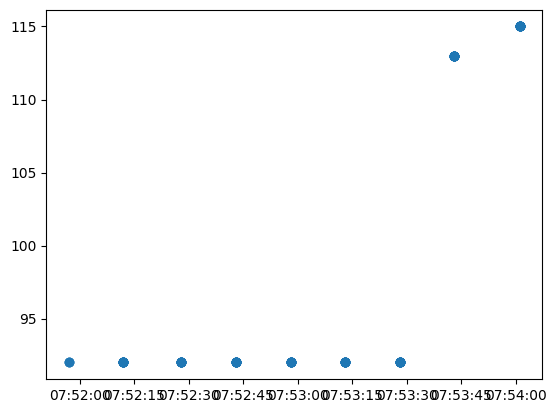

In [110]:
plt.scatter(df_trip_stop_8['feed_timestamp'], df_trip_stop_8['arrival_delay'])